# Treinamento de Modelo TextCat com spaCy para Classificação de Tweets

Este notebook demonstra como treinar um modelo de classificação de texto usando o componente textcat do spaCy para classificar tweets como relevantes (1) ou não relevantes (0).

## 1. Install and Import Libraries

Instale as bibliotecas necessárias e importe os módulos.

In [15]:
import sys
!{sys.executable} -m pip install --user spacy --upgrade

In [1]:

import spacy
import pandas as pd
from spacy.training import Example
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import os

## 2. Load the Dataset

Carregue o arquivo Excel e visualize os dados.

In [2]:
df = pd.read_excel("BASE (1).xlsx")
print(df.head())
print(df['RELEVANTE'].value_counts())

   RELEVANTE                                              TWEET
0          1  Ngl, none of the marketing is revealing any we...
1          1  The Barbie advertising team is working overtim...
2          1  ME AND ALL MY GAY FRIENDS GOING TO OUR PRIVATE...
3          1                 Me in the theater watching Barbie.
4          1  I need for Oppenheimer and Dune to come hard w...
RELEVANTE
0    1192
1    1075
Name: count, dtype: int64


## 3. Preprocess the Data

Limpe e pré-processe os dados de texto.

In [4]:
# Remover linhas com valores ausentes
df = df.dropna()

# Converter texto para minúsculas (exemplo simples de pré-processamento)
df['TWEET'] = df['TWEET'].astype(str).str.lower()

# Garantir que RELEVANTE seja int
df['RELEVANTE'] = df['RELEVANTE'].astype(int)

print(f"Dataset size: {len(df)}")

Dataset size: 2267


## 4. Prepare Training Data

Formate os dados no formato exigido pelo spaCy para treinamento.

In [7]:
# Preparar dados de treinamento
train_data = []
for _, row in df.iterrows():
    cats = {"RELEVANTE": 1 if row['RELEVANTE'] == 1 else 0, "NAO_RELEVANTE": 1 if row['RELEVANTE'] == 0 else 0}
    train_data.append((row['TWEET'], cats))

# Dividir em treino e teste
train_texts, test_texts, train_cats, test_cats = train_test_split(
    [text for text, _ in train_data], 
    [cats for _, cats in train_data], 
    test_size=0.2, random_state=42
)

print(f"Treino: {len(train_texts)}, Teste: {len(test_texts)}")

Treino: 1813, Teste: 454


## 5. Train the Model

Inicialize e treine o modelo spaCy com o componente textcat.

In [8]:
import spacy
from spacy.training import Example

# Criar um modelo blank em inglês (não requer lookups)
nlp = spacy.blank("en")

# Adicionar componente textcat
textcat = nlp.add_pipe("textcat")

# Adicionar labels
textcat.add_label("RELEVANTE")
textcat.add_label("NAO_RELEVANTE")

# Preparar exemplos de treinamento apenas com dados de treino
train_examples = []
for text, cats in zip(train_texts, train_cats):
    doc = nlp.make_doc(text)
    example = Example.from_dict(doc, {"cats": cats})
    train_examples.append(example)

# Treinar o modelo
optimizer = nlp.begin_training()
all_losses = []
for epoch in range(10):
    random.shuffle(train_examples)
    losses = {}
    for batch in spacy.util.minibatch(train_examples, size=8):
        nlp.update(batch, losses=losses)
    all_losses.append(losses.get('textcat', 0))
    print(f"Epoch {epoch+1}, Losses: {losses}")

Epoch 1, Losses: {'textcat': 28.057133650370815}
Epoch 2, Losses: {'textcat': 11.946961469841085}
Epoch 3, Losses: {'textcat': 5.276828735431463}
Epoch 4, Losses: {'textcat': 1.5904689686822917}
Epoch 5, Losses: {'textcat': 1.282376215359894}
Epoch 6, Losses: {'textcat': 1.0813204629061455}
Epoch 7, Losses: {'textcat': 0.85866713646398}
Epoch 8, Losses: {'textcat': 0.3397395209521251}
Epoch 9, Losses: {'textcat': 0.5010992597438754}
Epoch 10, Losses: {'textcat': 0.554287504881239}


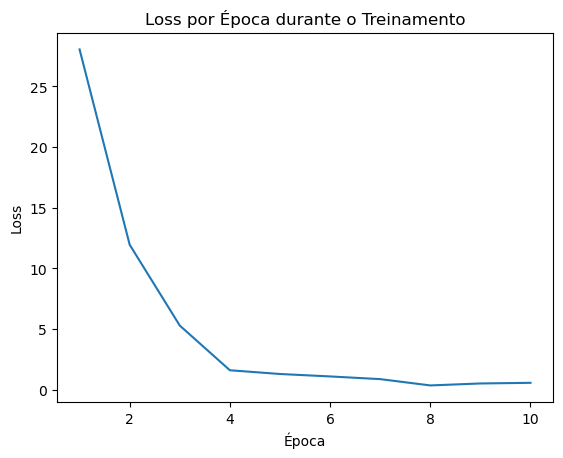

In [9]:
# Plotar a loss por época
plt.plot(range(1, 11), all_losses)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss por Época durante o Treinamento')
plt.show()

## 6. Evaluate the Model

Avalie o desempenho do modelo no conjunto de teste.

In [10]:
# Avaliar no conjunto de teste
y_true = []
y_pred = []

for text, true_cats in zip(test_texts, test_cats):
    doc = nlp(text)
    pred_cats = doc.cats
    y_true.append(true_cats['RELEVANTE'])
    y_pred.append(1 if pred_cats['RELEVANTE'] > 0.5 else 0)

print(classification_report(y_true, y_pred, target_names=['NAO_RELEVANTE', 'RELEVANTE']))

               precision    recall  f1-score   support

NAO_RELEVANTE       0.93      0.86      0.89       236
    RELEVANTE       0.86      0.93      0.89       218

     accuracy                           0.89       454
    macro avg       0.89      0.89      0.89       454
 weighted avg       0.89      0.89      0.89       454



## 7. Save and Load the Model

Salve o modelo treinado e demonstre como carregá-lo.

In [11]:
# Salvar o modelo
nlp.to_disk("modelo_textcat")

# Carregar o modelo (exemplo)
# nlp_loaded = spacy.load("modelo_textcat")
# print("Modelo salvo e carregado com sucesso!")

## 8. Classify New Text

Use o modelo treinado para classificar novos tweets.

In [14]:
import os
import pandas as pd

def classify_tweet(text):
    doc = nlp(text)
    return 1 if doc.cats['RELEVANTE'] > 0.5 else 0

# Classificação em arquivo
def classify_file(file_path, text_column="TWEET", output_filename="classificacoes.csv"):
    """
    Classifica os textos de um arquivo (CSV ou Excel) e salva o resultado em CSV
    
    Args:
        file_path: caminho do arquivo (.csv ou .xlsx) com coluna de texto
        text_column: nome da coluna contendo os textos (padrão: TWEET)
        output_filename: nome do arquivo CSV de saída (padrão: classificacoes.csv)
    """
    # Detectar tipo de arquivo e ler
    if file_path.lower().endswith('.csv'):
        df_input = pd.read_csv(file_path)
    else:
        df_input = pd.read_excel(file_path)
    
    print(f"Arquivo carregado! Colunas disponíveis: {list(df_input.columns)}")
    
    # Verificar se a coluna de texto existe
    if text_column not in df_input.columns:
        print(f"ERRO: Coluna '{text_column}' não encontrada!")
        return None
    
    # Classificar cada tweet/texto
    df_input['CLASSIFICACAO'] = df_input[text_column].apply(lambda x: classify_tweet(str(x)))
    
    # Salvar em CSV na pasta raiz
    output_path = os.path.join(os.getcwd(), output_filename)
    df_input.to_csv(output_path, index=False, encoding='utf-8')
    
    print(f"\n✓ Arquivo classificado salvo em: {output_path}")
    print(f"Total de textos: {len(df_input)}")
    print(f"Relevantes: {(df_input['CLASSIFICACAO'] == 1).sum()}")
    print(f"Não relevantes: {(df_input['CLASSIFICACAO'] == 0).sum()}")
    
    return df_input


file_to_classify = r"C:\PROJETOS\TCC\TCC\TCC_02\6 TRADUCAO_TWEETS\tweets_526896_morbius_translated.csv"

# Especifique o nome correto da coluna com os textos (veja as colunas disponíveis)
resultado = classify_file(file_to_classify, text_column="text")  # Ajuste "text" para o nome correto
resultado.head()

Arquivo carregado! Colunas disponíveis: ['query', 'tweet_date', 'username', 'name', 'text', 'url', 'translated_text']

✓ Arquivo classificado salvo em: c:\PROJETOS\TCC\TCC\TCC_02\TREINO MODELO TEXTCAT\classificacoes.csv
Total de textos: 2000
Relevantes: 715
Não relevantes: 1285


,query,tweet_date,username,name,text,url,translated_text,CLASSIFICACAO
0,Morbius trailer,28 Feb 2022,@GilaFilmID,GilaFilmID,"Ntar kalo diundur lagi, tinggal rilis 'Final T...",https://nitter.net/GilaFilmID/status/149844617...,"Later, if it's postponed again, just release '...",0
1,Morbius trailer,28 Feb 2022,@DOReviewMovies,DO Review Movies,Trailer: Morbius from Sony Pictures in Theater...,https://nitter.net/DOReviewMovies/status/14984...,Trailer: Morbius from Sony Pictures in Theater...,0
2,Morbius trailer,28 Feb 2022,@MCU_Fanatics,MCU Fanatics,The final trailer for Morbius is sparking conv...,https://nitter.net/MCU_Fanatics/status/1498444...,The final trailer for Morbius is sparking conv...,0
3,Morbius trailer,28 Feb 2022,@MZilla1954,M Zilla1954,Did you know that Horizon shown in the #Morbiu...,https://nitter.net/MZilla1954/status/149844416...,Did you know that Horizon shown in the #Morbiu...,0
4,Morbius trailer,28 Feb 2022,@thetipbrat,The Tipbrat,Just watched the final trailer for Marvel's 'M...,https://nitter.net/thetipbrat/status/149844410...,Just watched the final trailer for Marvel's 'M...,1
